# Práctica — Preprocesamiento de Datos (Dataset WDBC)
**Objetivo:** Implementar un flujo universal de preprocesamiento de datos en Python aplicado al Wisconsin Diagnostic Breast Cancer (WDBC) dataset.

In [1]:
%pip install scikit-learn
# 0) Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# Le decimos a joblib que asuma que tienes 4 núcleos (puedes poner otro número)
# Esto evita que intente usar 'wmic' en Windows 11
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

# Librerías adicionales requeridas para la práctica
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore') # Para mantener el cuaderno limpio

Note: you may need to restart the kernel to use updated packages.


## 1) Carga universal del dataset
**ACTIVIDAD:** * **Nombre del archivo:** `wdbc.data`
* **Formato:** CSV (Valores separados por comas) sin encabezados nativos.
* **Separador:** `,`
* **Codificación:** `utf-8`
* **Columnas principales y objetivo:** La columna objetivo es `diagnosis` (M=Maligno, B=Benigno). Las demás son 30 características numéricas calculadas a partir de imágenes de células (radio, textura, perímetro, área, etc.).

In [2]:
# 1.1 Ruta del archivo
DATA_PATH = "wdbc.data" 

# Generación de nombres de columnas (ya que el archivo original no los trae)
features = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 
            'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
cols = ['id', 'diagnosis']
for suffix in ['_mean', '_se', '_worst']:
    for f in features:
        cols.append(f + suffix)

# 1.2 Seleccione el tipo de archivo (Opción A: CSV con nombres personalizados)
df = pd.read_csv(DATA_PATH, sep=",", names=cols, encoding="utf-8")

# Verificación mínima
display(df.head(3))
print("Shape original:", df.shape)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


Shape original: (569, 32)


## 2) Vista rápida y perfil inicial (Data Quality)

**ACTIVIDAD (Hallazgos importantes):**
1. **Tipos de datos correctos:** Afortunadamente, a excepción de `diagnosis` (que es categórica tipo `object`), todas las variables celulares fueron interpretadas correctamente como `float64`. `id` es `int64`.
2. **Cero valores faltantes:** El dataset WDBC es famoso por estar pre-limpiado; no contiene nulos.
3. **Diferencias extremas de escala:** Al ver el `describe()`, notamos que variables como `smoothness_mean` rondan el 0.09, mientras que `area_mean` puede llegar a 2500. Esto hace **obligatorio** un escalamiento (normalización) posterior.

In [3]:
# 2.1 Resumen rápido
print("Filas, Columnas:", df.shape)

# 2.2 Tipos y nulos
display(pd.DataFrame({'Tipo': df.dtypes, 'Nulos': df.isna().sum()}).head(10))

# 2.3 Estadística numérica (mostramos solo algunas para ver el problema de escala)
display(df[['radius_mean', 'smoothness_mean', 'area_mean']].describe().T)

# 2.4 Estadística categórica
display(df.describe(include=["object"]).T)

Filas, Columnas: (569, 32)


,Tipo,Nulos
id,int64,0
diagnosis,object,0
radius_mean,float64,0
texture_mean,float64,0
perimeter_mean,float64,0
area_mean,float64,0
smoothness_mean,float64,0
compactness_mean,float64,0
concavity_mean,float64,0
concave_points_mean,float64,0


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000


,count,unique,top,freq
diagnosis,569,2,B,357


## 3) Data Cleaning — Valores faltantes (Missing Values)
**ACTIVIDAD:**
Aunque comprobamos en el paso 2 que **no hay valores faltantes** en este dataset, dejaremos implementada la **Opción C (imputación simple con mediana)** como buena práctica de ingeniería de datos. Si en el futuro ingresan nuevos pacientes con datos incompletos, el pipeline no fallará.

In [4]:
# 3.1 Identificar columnas por tipo
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('id') # El ID no es una variable analítica
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# 3.4 Opción C: imputación simple (Preventiva)
df_clean = df.copy()

# --- numéricas: mediana ---
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# --- categóricas: moda ---
for c in cat_cols:
    if df_clean[c].isna().any():
        moda = df_clean[c].mode(dropna=True)
        df_clean[c] = df_clean[c].fillna(moda.iloc[0] if len(moda) > 0 else "DESCONOCIDO")

print("Nulos después del pipeline preventivo:", df_clean.isna().sum().sum())

Nulos después del pipeline preventivo: 0


## 4) Data Cleaning — Ruido, outliers y formatos (Noisy Data)

**ACTIVIDAD:**
Evaluaremos `area_mean`, `radius_mean` y `texture_mean`. 
* **Justificación de la técnica:** Aplicaremos **Winsorize (capping / recortes a límites)** en lugar de eliminar filas. ¿Por qué? En oncología, los tumores malignos suelen ser *naturalmente* mucho más grandes que los benignos. Si eliminamos los outliers, ¡podríamos estar borrando los casos más severos de cáncer! Limitarlos (capping) suaviza el ruido extremo sin perder al paciente.

In [5]:
cols_check = ['area_mean', 'radius_mean', 'texture_mean']

# 4.1 Outliers por IQR
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

# Opción B: cap/winsorize (recortar a límites)
df_clean2 = df_clean.copy()
for c in cols_check:
    lo, hi = iqr_bounds(df_clean2[c].dropna())
    df_clean2[c] = df_clean2[c].clip(lo, hi)

print("Estadísticas tras el Capping (Note que los valores 'max' han disminuido):")
display(df_clean2[cols_check].describe().T)

Estadísticas tras el Capping (Note que los valores 'max' han disminuido):


,count,mean,std,min,25%,50%,75%,max
area_mean,569.0,639.765202,305.343508,143.500,420.30,551.10,782.70,1326.300
radius_mean,569.0,14.062916,3.340025,6.981,11.70,13.37,15.78,21.900
texture_mean,569.0,19.254736,4.187510,9.710,16.17,18.84,21.80,30.245


## 5) Data Integration — Unión de fuentes
**ACTIVIDAD:** No aplica. Solo se usó una fuente central (`wdbc.data`). No hay conflictos de llaves foráneas ni redundancia entre múltiples bases de datos.

## 6) Data Reduction — Reducción de datos

**ACTIVIDAD:** Aplicaremos **PCA (Análisis de Componentes Principales)**. Tenemos 30 variables numéricas, lo cual es alta dimensionalidad. El PCA nos permitirá comprimir esta información en solo 2 componentes principales para visualizar si existe una separación natural entre tumores benignos y malignos.

Varianza explicada por PC1: 44.14%
Varianza explicada por PC2: 18.93%
Total de información retenida en 2D: 63.07%


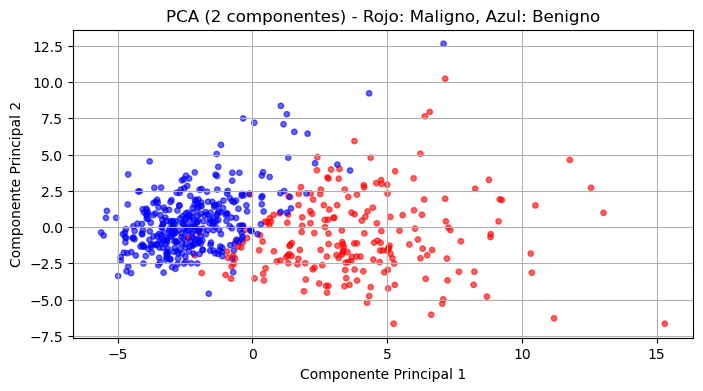

In [6]:
# 6.2 PCA
base = df_clean2
# Tomamos solo las variables celulares numéricas (excluimos ID)
X = base[num_cols].dropna().to_numpy()

# Escalado obligatorio previo a PCA
Xz = StandardScaler().fit_transform(X)
pca = PCA(n_components=2) 
Z = pca.fit_transform(Xz)

var_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_explicada[0]:.2%}")
print(f"Varianza explicada por PC2: {var_explicada[1]:.2%}")
print(f"Total de información retenida en 2D: {var_explicada.sum():.2%}")

# Visualización
colores = base['diagnosis'].map({'M': 'red', 'B': 'blue'})
plt.scatter(Z[:,0], Z[:,1], c=colores, s=15, alpha=0.6)
plt.title("PCA (2 componentes) - Rojo: Maligno, Azul: Benigno")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

## 7) Data Transformation — Normalización y escalamiento
**ACTIVIDAD:** Como vimos en el paso 2, las escalas difieren enormemente. Aplicaremos **Z-score** a todas las variables numéricas. Para la variable categórica (`diagnosis`), aplicaremos un mapeo binario manual (0 y 1) en lugar de One-Hot Encoding, ya que es una clasificación binaria simple.

In [7]:
base_t = df_clean2.copy()

# 7.1 Z-score para todas las variables celulares
scaler = StandardScaler()
base_t[num_cols] = scaler.fit_transform(base_t[num_cols])

# 7.3 Transformación de variable objetivo (Binaria)
base_t['diagnosis_num'] = base_t['diagnosis'].map({'M': 1, 'B': 0})

print("Vista de los datos transformados (Z-score aplicado):")
display(base_t[['radius_mean', 'texture_mean', 'diagnosis_num']].head())

Vista de los datos transformados (Z-score aplicado):


,radius_mean,texture_mean,diagnosis_num
0,1.176800,-2.121200,1
1,1.949929,-0.354875,1
2,1.686226,0.476899,1
3,-0.791983,0.268955,1
4,1.866023,-1.174698,1


## 8) Data Discretization — Binning y discretización por histograma
**ACTIVIDAD:** Discretizaremos la variable `radius_mean` original en 3 categorías (Pequeño, Mediano, Grande) utilizando cuantiles (Equal-frequency) para asegurar que haya una cantidad similar de pacientes en cada grupo.

In [8]:
# 8.2 Discretización por cuantiles (equal-frequency)
base_disc = base_t.copy()
# Usamos df_clean2 porque base_t ya tiene Z-score y es más difícil de interpretar
col = 'radius_mean' 
etiquetas = ['Pequeño', 'Mediano', 'Grande']

base_disc[col + "_bin_q"] = pd.qcut(df_clean2[col], q=3, labels=etiquetas)

display(base_disc[[col, col + "_bin_q"]].head())
print("\nDistribución de pacientes por tamaño de radio:")
display(base_disc[col + "_bin_q"].value_counts())

,radius_mean,radius_mean_bin_q
0,1.176800,Grande
1,1.949929,Grande
2,1.686226,Grande
3,-0.791983,Pequeño
4,1.866023,Grande



Distribución de pacientes por tamaño de radio:


radius_mean_bin_q
Pequeño    191
Grande     190
Mediano    188
Name: count, dtype: int64

## 9) Discretización por clustering
**ACTIVIDAD:** Aplicaremos K-Means a la variable `area_mean` para encontrar 3 agrupaciones naturales de tamaño de tumor dictadas puramente por las matemáticas espaciales, no por rangos fijos.

In [9]:
# 9.1 Discretización por clustering
col_cluster = 'area_mean'
X_cluster = df_clean2[[col_cluster]].to_numpy() # Usamos la escala original

km = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = km.fit_predict(X_cluster)

base_disc[col_cluster + "_cluster"] = clusters
print(f"Centroides encontrados para {col_cluster}: \n{km.cluster_centers_.flatten()}")
display(base_disc[[col_cluster, col_cluster + "_cluster"]].head())

Centroides encontrados para area_mean: 
[1162.78        398.28825758  658.72947368]


,area_mean,area_mean_cluster
0,1.184085,0
1,2.249396,0
2,1.846217,0
3,-0.831485,1
4,2.154338,0


## 10) Concept Hierarchy Generation (Nominal Data)
**ACTIVIDAD:** El dataset WDBC solo posee una variable categórica (`diagnosis` con M y B). No existe una jerarquía obvia (como Ciudad -> Estado). Sin embargo, conceptualmente, si tuviéramos grados de malignidad (ej. Grado I, Grado II, Grado III), podríamos jerarquizarlos agrupándolos todos bajo el concepto superior de "Maligno".

## 11) Exportación del dataset final
**ACTIVIDAD:** Exportamos el dataframe que contiene la limpieza, el escalamiento y la discretización. Utilizaremos el formato CSV.

In [10]:
# Definimos el dataset final preparado para Machine Learning
final_df = base_disc.drop(columns=['id']) # Eliminamos ID, ya no sirve

# Exportación
filename = "wdbc_preprocesado_final.csv"
final_df.to_csv(filename, index=False)
print(f"¡Exportación lista! Archivo guardado como: {filename}")

¡Exportación lista! Archivo guardado como: wdbc_preprocesado_final.csv


## 12) Conclusión (Respuestas)

1. **¿Qué problemas de calidad detectó?**
   El dataset original carecía de encabezados (nombres de columnas), lo que requirió definirlos manualmente leyendo la documentación (`wdbc.names`). Además, se detectó una variación masiva en las escalas de los datos (ej. fractal_dimension vs area_mean) y la presencia de outliers fuertes en las variables de tamaño. No se detectaron valores nulos.

2. **¿Qué técnicas aplicó y por qué?**
   * **Imputación por Mediana:** Se dejó programada como medida de seguridad para futuros ingresos de datos.
   * **Winsorización (Capping):** Se usó para limitar los outliers en lugar de eliminarlos, ya que los valores atípicos muy altos corresponden a tumores malignos reales; eliminarlos destruiría información clínica crítica.
   * **Z-Score (Estandarización):** Obligatoria porque las distancias matemáticas entre variables con escalas tan distintas arruinarían cualquier algoritmo.
   * **PCA:** Para reducir dimensionalidad (de 30 a 2 variables) y demostrar visualmente la separabilidad de las clases.
   * **Discretización (Qcut y KMeans):** Para agrupar pacientes clínicamente por el tamaño de sus tumores (Pequeño/Mediano/Grande).

3. **¿Qué cambió en el dataset (filas/columnas/rangos)?**
   * Las filas (569) se mantuvieron intactas, preservando el 100% de la muestra de pacientes.
   * Se modificaron los rangos numéricos extremos al aplicar Capping en los outliers.
   * Se cambiaron totalmente las magnitudes de las 30 variables continuas al aplicar el Z-score (ahora centradas en 0).
   * Se agregaron nuevas columnas categóricas producto de la discretización.

4. **¿Qué riesgos quedan (posibles sesgos, pérdida de información)?**
   El mayor riesgo introducido es el **capping de los outliers**. Al limitar matemáticamente el tamaño máximo del área o el radio de los tumores más agresivos, el futuro modelo predictivo podría perder la sensibilidad para distinguir entre un tumor moderadamente maligno y uno extremadamente maligno, ya que ambos tendrían el mismo valor "tope".